In [16]:
import urllib
import os,sys
import numpy as np
import pandas as pd

from sklearn import feature_extraction
from sklearn import preprocessing
from random import seed, shuffle
#from __future__ import division
#from collections import defaultdict
#import utils as ut

SEED = 1234
seed(SEED)
np.random.seed(SEED)

def check_data_file(fname):
    files = os.listdir(".") # get the current directory listing
    print("Looking for file '%s' in the current directory...",fname)

    if fname not in files:
        print("'%s' not found! Downloading from GitHub...",fname)
        addr = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
        response = urllib.request.urlopen(addr)
        data = response.read()
        fileOut = open(fname, "wb")
        fileOut.write(data)
        fileOut.close()
        print("'%s' download and saved locally..",fname)
    else:
        print("File found in current directory..")

COMPAS_INPUT_FILE = "compas-scores-two-years.csv"
check_data_file(COMPAS_INPUT_FILE)

Looking for file '%s' in the current directory... compas-scores-two-years.csv
File found in current directory..


In [51]:
# load the file
df = pd.read_csv(COMPAS_INPUT_FILE)
# print(df.shape)

df = df.dropna(subset=["days_b_screening_arrest"]) # dropping missing vals

df = df[
    (df.days_b_screening_arrest <= 30) &
    (df.days_b_screening_arrest >= -30) &
    (df.is_recid != -1) &
    (df.c_charge_degree != 'O') &
    (df.score_text != 'N/A')
]

df.reset_index(inplace=True, drop=True) # renumber the rows from 0 again
# df.shape

# Conversion to dictionary with np arrays
data = df.to_dict('list')
for k in data.keys():
    data[k] = np.array(data[k])

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import defaultdict

# Updated lists
FEATURES_CLASSIFICATION = [
    "age_cat", "race", "sex", "priors_count", "c_charge_degree"
]
CONT_VARIABLES = ["priors_count"]
CLASS_FEATURE = "two_year_recid" # the decision variable
SENSITIVE_ATTRS = ["race"]

y = data[CLASS_FEATURE]
X = np.array([]).reshape(len(y), 0) # empty array with num rows same as num examples, will hstack the features to it
FEATURE_NAMES = []
x_control = defaultdict(list)

for attr in FEATURES_CLASSIFICATION:
    vals = data[attr]
    if attr in CONT_VARIABLES:
        vals = [float(v) for v in vals]
        vals = preprocessing.scale(vals) # 0 mean and 1 variance
        vals = np.reshape(vals, (len(y), -1)) # convert from 1-d arr to a 2-d arr with one col
        FEATURE_NAMES.append(attr)
    else: # this encodes categorical variables in a numerical way -- there are other ways to do it
        enc = preprocessing.LabelBinarizer()
        enc.fit(vals)
        vals = enc.transform(vals)
        if vals.ndim == 1 or (vals.ndim == 2 and vals.shape[1] == 1):
            vals = np.reshape(vals, (len(y), -1))
            FEATURE_NAMES.append(attr)
        else:
            FEATURE_NAMES.extend([f"{attr}_{val}" for val in enc.classes_])

    # add to learnable features
    X = np.hstack((X, vals))


# the following is a very dirty way to keep track of the race after the train_test_split
ind = data["race"]=="African-American"
X_b = X[ind]
y_b = y[ind]
ind = data["race"]=="Caucasian"
X_w = X[ind]
y_w = y[ind]
ind = [data["race"][i]!="Caucasian" and data["race"][i]!="African-American" for i in range(len(y))]
X_n = X[ind]
y_n = y[ind]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.3, random_state=1234)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.3, random_state=5678)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_n, y_n, test_size=0.3, random_state=9012)

X_train = np.vstack((X_train_b, X_train_w, X_train_n))
y_train = np.hstack((y_train_b, y_train_w, y_train_n))
X_test = np.vstack((X_test_b, X_test_w, X_test_n))
y_test = np.hstack((y_test_b, y_test_w, y_test_n))




# TODO: Uncomment and complete the code below# ...

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
df.columns
#df['juv_misd_count'].unique()
#df['juv_other_count'].unique()
#df["c_charge_desc"]

#'juv_misd_count' , 'juv_other_count'



Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')

In [70]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

Accuracy: 0.6540744738262277
Model coefficients: [[-0.12337318 -0.81391275  0.64325427  0.17097426 -0.36548585  0.13596979
  -0.1870776   0.0097269  -0.05813917  0.3320482   0.84147477 -0.2598156 ]]
Model intercept: [-0.35756435]


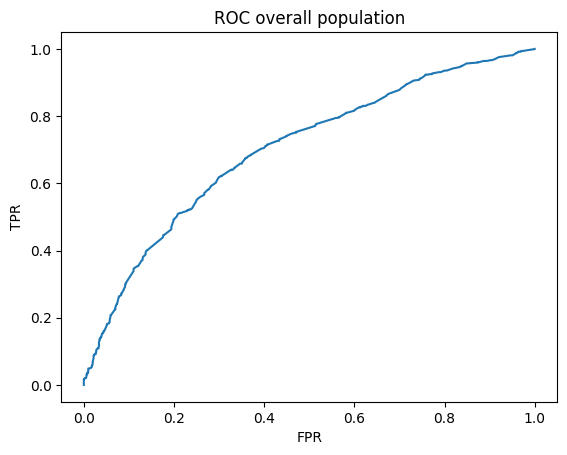

In [71]:
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])

plt.plot(fpr, tpr)

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


In [72]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(5)
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [73]:
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))


Accuracy: 0.6405828386400432


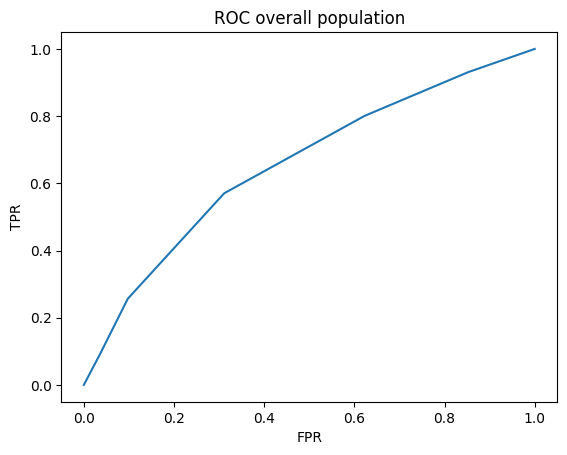

In [57]:
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])

plt.plot(fpr, tpr)

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


In [74]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5,random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Accuracy: 0.6637884511602806


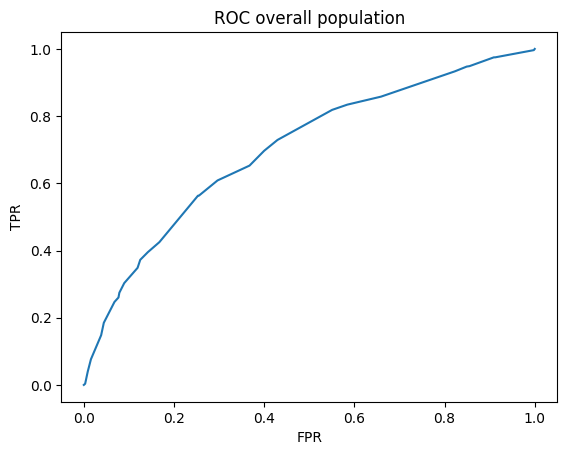

In [75]:
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))


from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])

plt.plot(fpr, tpr)

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


In [76]:
FEATURE_NAMES

['age_cat_25 - 45',
 'age_cat_Greater than 45',
 'age_cat_Less than 25',
 'race_African-American',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Native American',
 'race_Other',
 'sex',
 'priors_count',
 'c_charge_degree']

In [77]:

print(FEATURE_NAMES[4])
print(type(X_train))
print(X_train.shape)
print(X_train[0,4])


race_Asian
<class 'numpy.ndarray'>
(4319, 12)
0.0


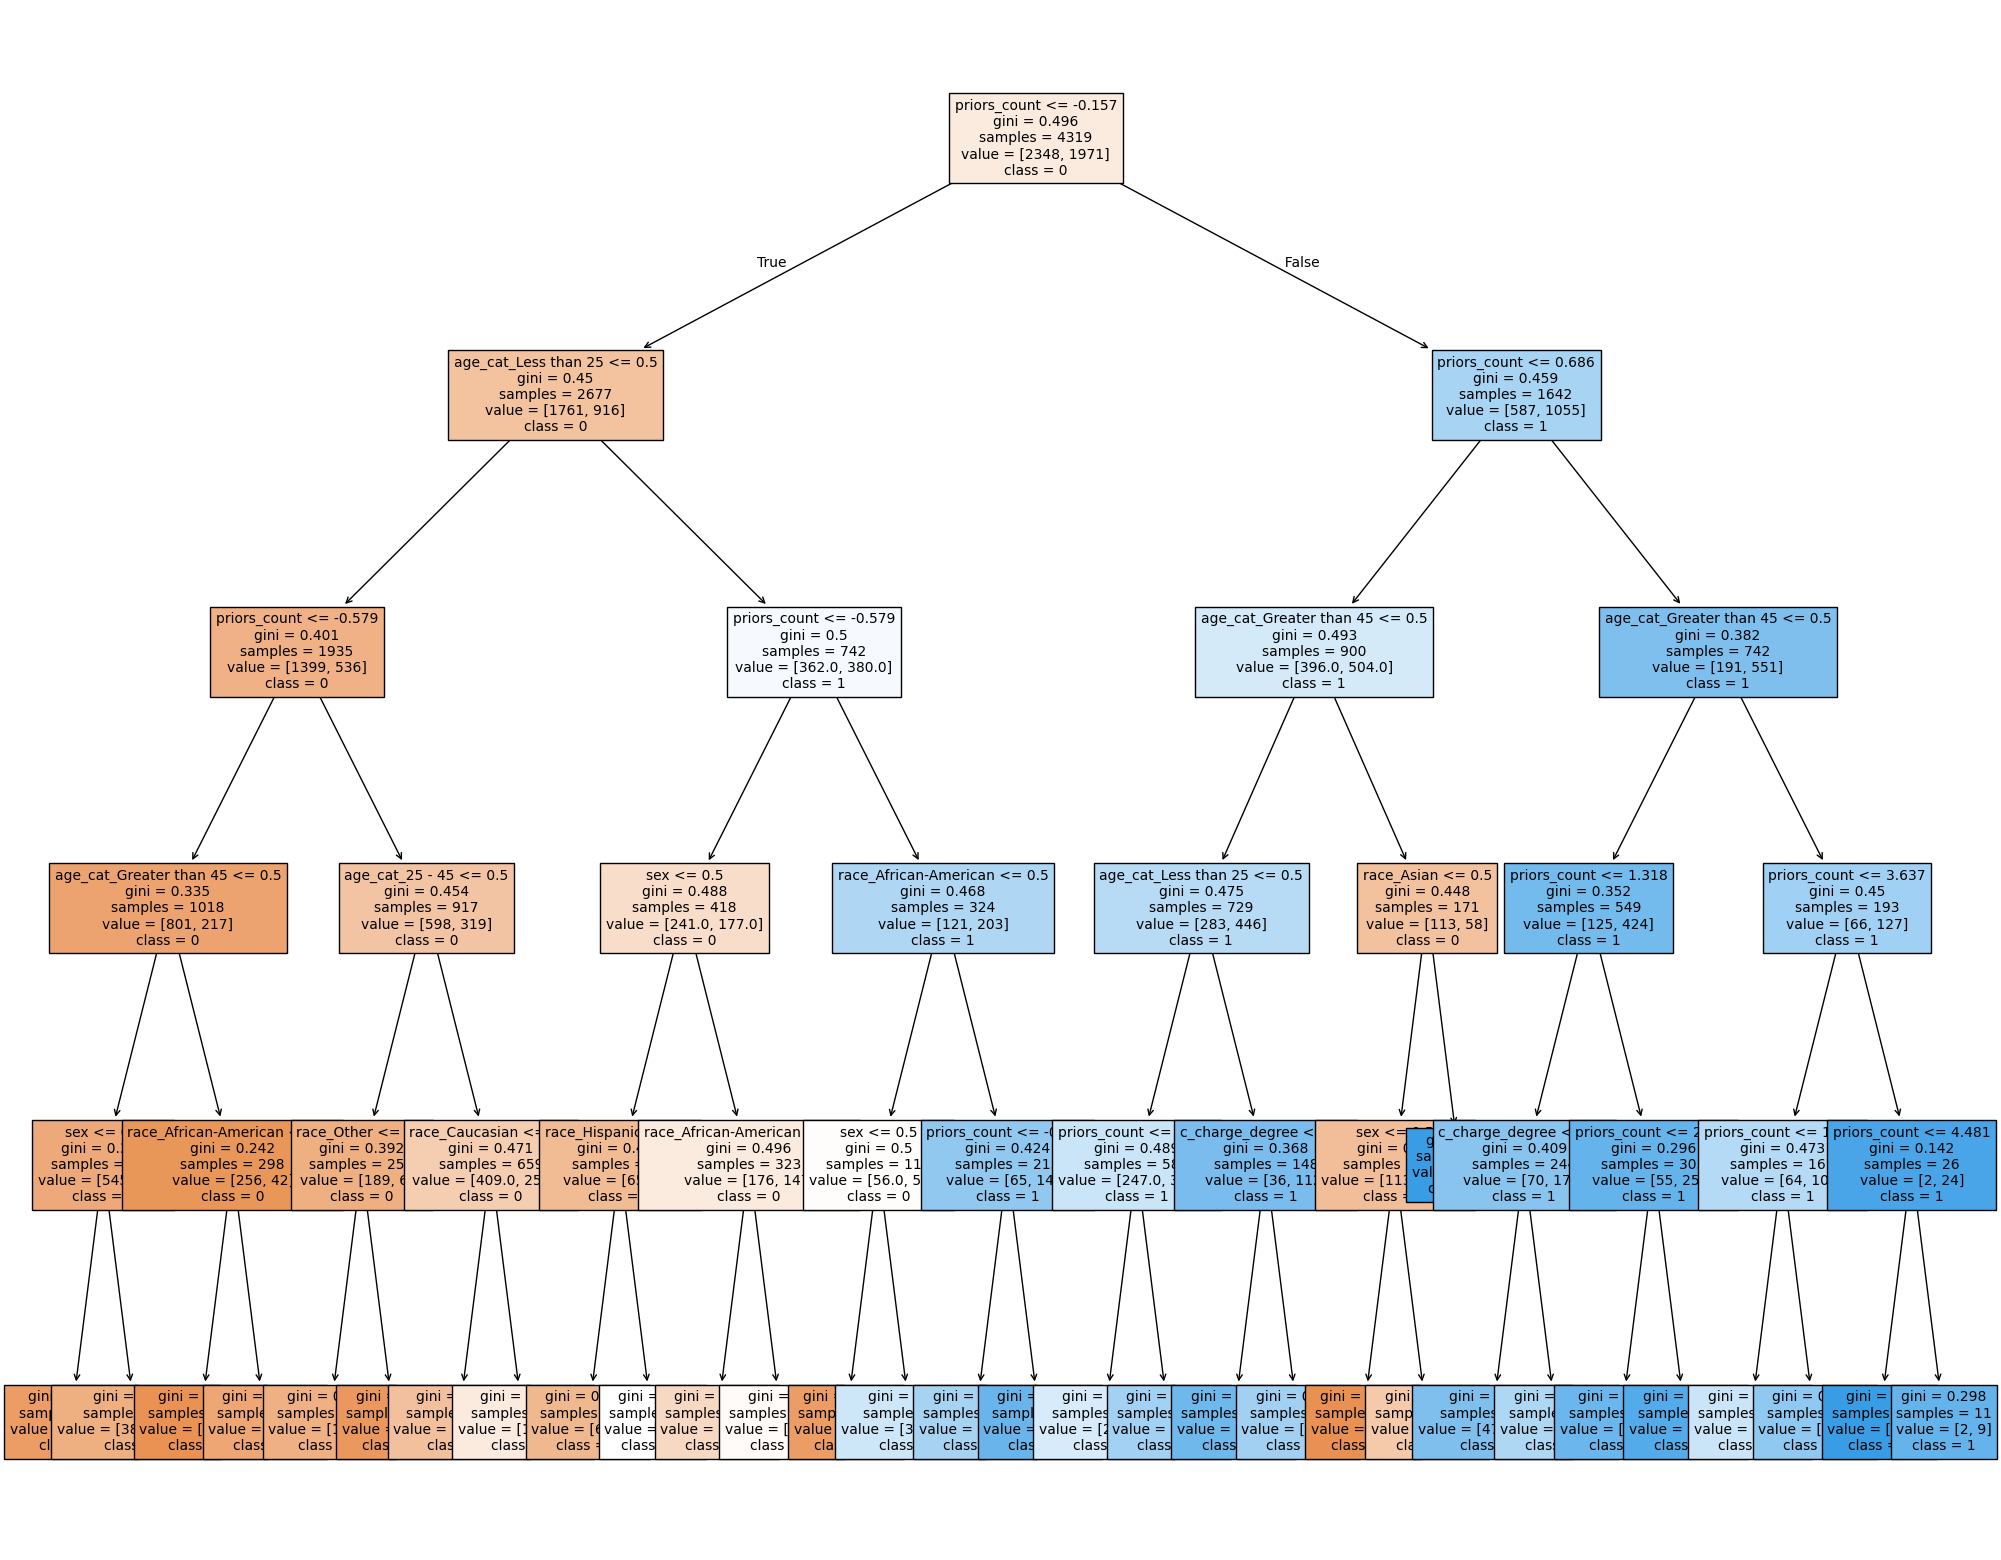

In [78]:
from sklearn import tree

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(model,
                   feature_names=FEATURE_NAMES,
                   class_names=[str(c) for c in model.classes_],
                   fontsize=10,
                   filled=True)

In [79]:
# cm is a confusion matrix. The rows are guessed, the columns are actual
def print_ppv_fpv(cm):
    # the indices here are [col][row] or [actual][guessed]
    TN = cm[False][False]
    TP = cm[True][True]
    FN = cm[True][False]
    FP = cm[False][True]
# TODO: Uncomment the lines below and replace the ... by the appropriate expressions of TN, TP, FN, FP
    print('Accuracy: ', (TP+TN)/(TP+TN+FN+FP))
    print('PPV: ', TP/(TP+FP))
    print('FPR: ', FP/(FP+TN))
    print('FNR: ', FN/(TP+FN))
    print()
#


def print_metrics(guessed, actual):
    cm = pd.crosstab(guessed, actual, rownames=['guessed'], colnames=['actual'])
    print(cm)
    print()
    print_ppv_fpv(cm)

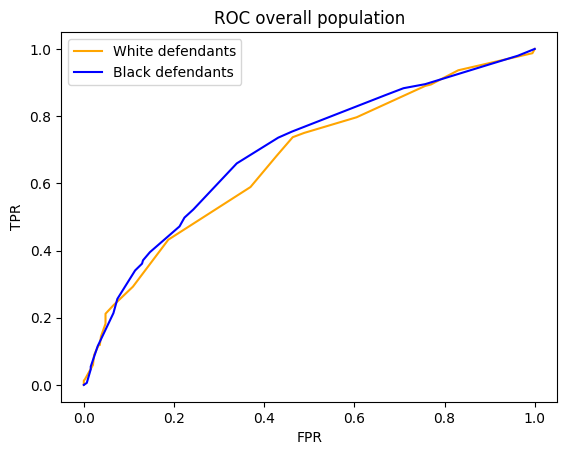

In [80]:

whitescores = model.predict_proba(X_test_w)
blackscores = model.predict_proba(X_test_b)
scores = model.predict_proba(X_test)

whitefpr, whitetpr, thresholds = roc_curve(y_test_w, whitescores[:,1])
blackfpr, blacktpr, thresholds = roc_curve(y_test_b, blackscores[:,1])

plt.plot(whitefpr, whitetpr, label = 'White defendants', color = 'orange')
plt.plot(blackfpr, blacktpr, label= 'Black defendants', color = 'blue')
plt.legend()


plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [81]:
threshold_common = 0.5
# TODO: Insert your code below this line
whitepred = np.zeros(len(whitescores),)
blackpred = np.zeros(len(blackscores),)
pred = np.zeros(len(scores),)
for i in range(len(whitescores)):
  if (whitescores[i,1] >= threshold_common):
    whitepred[i] = 1
for i in range(len(blackscores)):
  if blackscores[i, 1] >= threshold_common:
    blackpred[i] = 1
for i in range(len(scores)):
  if scores[i, 1] >= threshold_common:
    pred[i] = 1

print("Total dataset")
print_metrics(pred.astype(bool), y_test.astype(bool))

print("White dataset")
print_metrics(whitepred.astype(bool), y_test_w.astype(bool))
print()
print("Black dataset")
print_metrics(blackpred.astype(bool), y_test_b.astype(bool))

#Lower FPR overall but still unfair

Total dataset
actual   False  True 
guessed              
False      756    366
True       259    472

Accuracy:  0.6627091203453859
PPV:  0.6456908344733242
FPR:  0.25517241379310346
FNR:  0.43675417661097854

White dataset
actual   False  True 
guessed              
False      321    134
True        74    102

Accuracy:  0.6703645007923931
PPV:  0.5795454545454546
FPR:  0.18734177215189873
FNR:  0.5677966101694916


Black dataset
actual   False  True 
guessed              
False      302    169
True       155    327

Accuracy:  0.6600209863588667
PPV:  0.6784232365145229
FPR:  0.33916849015317285
FNR:  0.3407258064516129



In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import defaultdict

FEATURES_CLASSIFICATION = ["age_cat", "sex", "priors_count", "c_charge_degree"] #features to be used for classification
CONT_VARIABLES = ["priors_count"] # continuous features, will need to be handled separately from categorical features, categorical features will be encoded using one-hot
CLASS_FEATURE = "two_year_recid" # the decision variable
SENSITIVE_ATTRS = ["race"]


y = data[CLASS_FEATURE]
X = np.array([]).reshape(len(y), 0) # empty array with num rows same as num examples, will hstack the features to it
FEATURE_NAMES = []
x_control = defaultdict(list)

for attr in FEATURES_CLASSIFICATION:
    vals = data[attr]
    if attr in CONT_VARIABLES:
        vals = [float(v) for v in vals]
        vals = preprocessing.scale(vals) # 0 mean and 1 variance
        vals = np.reshape(vals, (len(y), -1)) # convert from 1-d arr to a 2-d arr with one col
        FEATURE_NAMES.append(attr)
    else: # this encodes categorical variables in a numerical way -- there are other ways to do it
        enc = preprocessing.LabelBinarizer()
        enc.fit(vals)
        vals = enc.transform(vals)
        if vals.ndim == 1 or (vals.ndim == 2 and vals.shape[1] == 1):
            vals = np.reshape(vals, (len(y), -1))
            FEATURE_NAMES.append(attr)
        else:
            FEATURE_NAMES.extend([f"{attr}_{val}" for val in enc.classes_])

    # add to learnable features
    X = np.hstack((X, vals))


# the following is a very dirty way to keep track of the race after the train_test_split
ind = data["race"]=="African-American"
X_b = X[ind]
y_b = y[ind]
ind = data["race"]=="Caucasian"
X_w = X[ind]
y_w = y[ind]
ind = [data["race"][i]!="Caucasian" and data["race"][i]!="African-American" for i in range(len(y))]
X_n = X[ind]
y_n = y[ind]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.3, random_state=1234)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.3, random_state=5678)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_n, y_n, test_size=0.3, random_state=9012)

X_train = np.vstack((X_train_b, X_train_w, X_train_n))
y_train = np.hstack((y_train_b, y_train_w, y_train_n))
X_test = np.vstack((X_test_b, X_test_w, X_test_n))
y_test = np.hstack((y_test_b, y_test_w, y_test_n))




# TODO: Uncomment and complete the code below# ...

model = DecisionTreeClassifier(max_depth=5,random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Accuracy: 0.6659471127900701
[[0.87356322 0.12643678]
 [0.81958763 0.18041237]
 [0.44303797 0.55696203]
 ...
 [0.44303797 0.55696203]
 [0.44303797 0.55696203]
 [0.81958763 0.18041237]]


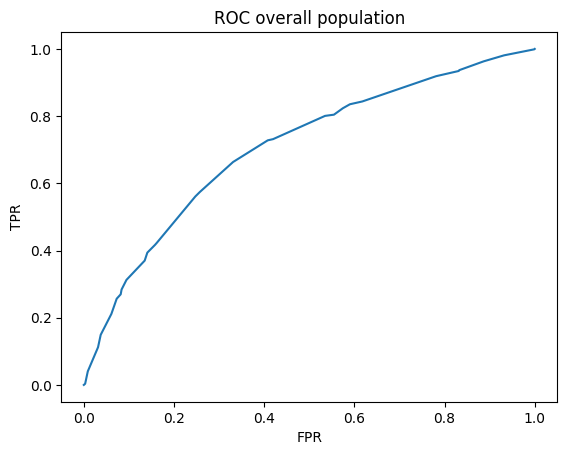

In [83]:
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))


from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

scores = model.predict_proba(X_test)
print(scores)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])

plt.plot(fpr, tpr)

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


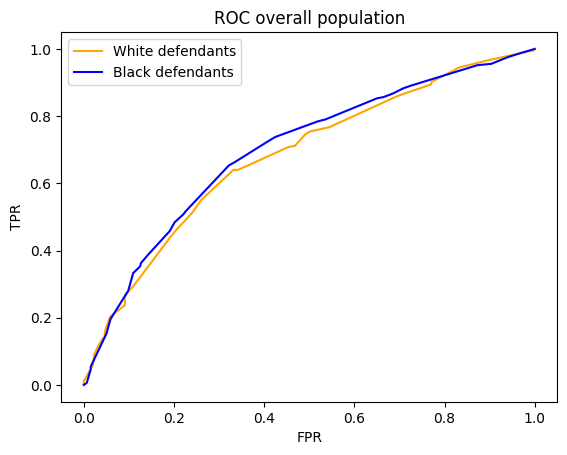

In [84]:

whitescores = model.predict_proba(X_test_w)
blackscores = model.predict_proba(X_test_b)
scores = model.predict_proba(X_test)

whitefpr, whitetpr, thresholds = roc_curve(y_test_w, whitescores[:,1])
blackfpr, blacktpr, thresholds = roc_curve(y_test_b, blackscores[:,1])

plt.plot(whitefpr, whitetpr, label = 'White defendants', color = 'orange')
plt.plot(blackfpr, blacktpr, label= 'Black defendants', color = 'blue')
plt.legend()


plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [85]:
threshold_common = 0.5
# TODO: Insert your code below this line
whitepred = np.zeros(len(whitescores),)
blackpred = np.zeros(len(blackscores),)
pred = np.zeros(len(scores),)
for i in range(len(whitescores)):
  if (whitescores[i,1] >= threshold_common):
    whitepred[i] = 1
for i in range(len(blackscores)):
  if blackscores[i, 1] >= threshold_common:
    blackpred[i] = 1
for i in range(len(scores)):
  if scores[i, 1] >= threshold_common:
    pred[i] = 1

print("Total dataset")
print_metrics(pred.astype(bool), y_test.astype(bool))

print("White dataset")
print_metrics(whitepred.astype(bool), y_test_w.astype(bool))
print()
print("Black dataset")
print_metrics(blackpred.astype(bool), y_test_b.astype(bool))

#Lower FPR overall but still unfair

Total dataset
actual   False  True 
guessed              
False      754    357
True       261    481

Accuracy:  0.6664867781975176
PPV:  0.6482479784366577
FPR:  0.2571428571428571
FNR:  0.42601431980906923

White dataset
actual   False  True 
guessed              
False      315    128
True        80    108

Accuracy:  0.6703645007923931
PPV:  0.574468085106383
FPR:  0.20253164556962025
FNR:  0.5423728813559322


Black dataset
actual   False  True 
guessed              
False      305    168
True       152    328

Accuracy:  0.664218258132214
PPV:  0.6833333333333333
FPR:  0.33260393873085337
FNR:  0.3387096774193548



In [86]:
threshold_black = 0.6
threshold_white = 0.5
# TODO: Insert your code below this line
whitepred = np.zeros(len(whitescores),)
blackpred = np.zeros(len(blackscores),)
pred = np.zeros(len(scores),)
for i in range(len(whitescores)):
  if (whitescores[i,1] >= threshold_white):
    whitepred[i] = 1
for i in range(len(blackscores)):
  if blackscores[i, 1] >= threshold_black:
    blackpred[i] = 1
for i in range(len(scores)):
  if scores[i, 1] >= threshold_common:
    pred[i] = 1

print("Total dataset")
pred_conc = np.concatenate((whitepred, blackpred))
y_test_conc = np.concatenate((y_test_w, y_test_b))
print_metrics(pred_conc.astype(bool), y_test_conc.astype(bool))

print("White dataset")
print_metrics(whitepred.astype(bool), y_test_w.astype(bool))
print()
print("Black dataset")
print_metrics(blackpred.astype(bool), y_test_b.astype(bool))

#Lower FPR overall but still unfair

Total dataset
actual   False  True 
guessed              
False      680    384
True       172    348

Accuracy:  0.648989898989899
PPV:  0.6692307692307692
FPR:  0.20187793427230047
FNR:  0.5245901639344263

White dataset
actual   False  True 
guessed              
False      315    128
True        80    108

Accuracy:  0.6703645007923931
PPV:  0.574468085106383
FPR:  0.20253164556962025
FNR:  0.5423728813559322


Black dataset
actual   False  True 
guessed              
False      365    256
True        92    240

Accuracy:  0.6348373557187827
PPV:  0.7228915662650602
FPR:  0.2013129102844639
FNR:  0.5161290322580645

